In [4]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import norm

import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
url = "https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/293/original/walmart_data.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [6]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [7]:
df.tail()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
550063,1006033,P00372445,M,51-55,13,B,1,1,20,368
550064,1006035,P00375436,F,26-35,1,C,3,0,20,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,365
550067,1006039,P00371644,F,46-50,0,B,4+,1,20,490


In [8]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 550068
Number of columns: 10


In [9]:
print("Column names:")
print(df.columns.tolist())

Column names:
['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category', 'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category', 'Purchase']


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


In [11]:
df.dtypes

,0
User_ID,int64
Product_ID,object
Gender,object
Age,object
Occupation,int64
City_Category,object
Stay_In_Current_City_Years,object
Marital_Status,int64
Product_Category,int64
Purchase,int64


In [12]:
categorical_columns = [
    'Gender',
    'Age',
    'City_Category',
    'Stay_In_Current_City_Years'
]

for col in categorical_columns:
    df[col] = df[col].astype('category')

df.dtypes

,0
User_ID,int64
Product_ID,object
Gender,category
Age,category
Occupation,int64
City_Category,category
Stay_In_Current_City_Years,category
Marital_Status,int64
Product_Category,int64
Purchase,int64


In [13]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category,Purchase
count,550068.00,550068.00,550068.00,550068.00,550068.00
mean,1003028.84,8.08,0.41,5.40,9263.97
std,1727.59,6.52,0.49,3.94,5023.07
min,1000001.00,0.00,0.00,1.00,12.00
25%,1001516.00,2.00,0.00,1.00,5823.00
50%,1003077.00,7.00,0.00,5.00,8047.00
75%,1004478.00,14.00,1.00,8.00,12054.00
max,1006040.00,20.00,1.00,20.00,23961.00


In [14]:
df.describe(include='category')

,Gender,Age,City_Category,Stay_In_Current_City_Years
count,550068,550068,550068,550068
unique,2,7,3,5
top,M,26-35,B,1
freq,414259,219587,231173,193821


In [15]:
df['Purchase'].describe()

,Purchase
count,550068.00
mean,9263.97
std,5023.07
min,12.00
25%,5823.00
50%,8047.00
75%,12054.00
max,23961.00


In [16]:
purchase_mean = df['Purchase'].mean()
purchase_median = df['Purchase'].median()

print("Mean Purchase:", purchase_mean)
print("Median Purchase:", purchase_median)
print("Difference between Mean and Median:", purchase_mean - purchase_median)

Mean Purchase: 9263.968712959126
Median Purchase: 8047.0
Difference between Mean and Median: 1216.9687129591257


In [17]:
missing_values = df.isnull().sum()

missing_values

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category,0
Purchase,0


In [18]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

,0
User_ID,0.00
Product_ID,0.00
Gender,0.00
Age,0.00
Occupation,0.00
City_Category,0.00
Stay_In_Current_City_Years,0.00
Marital_Status,0.00
Product_Category,0.00
Purchase,0.00


In [21]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [22]:
# We do not need to remove duplicates if duplicate_count is 0.

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicate rows found.")

No duplicate rows found.


In [24]:
df.nunique()

,0
User_ID,5891
Product_ID,3631
Gender,2
Age,7
Occupation,21
City_Category,3
Stay_In_Current_City_Years,5
Marital_Status,2
Product_Category,20
Purchase,18105


In [25]:
df['Gender'].value_counts()

,count
Gender,
M,414259
F,135809


In [26]:
df['Gender'].value_counts(normalize=True) * 100

,proportion
Gender,
M,75.31
F,24.69


In [27]:
df['Age'].value_counts()

,count
Age,
26-35,219587
36-45,110013
18-25,99660
46-50,45701
51-55,38501
55+,21504
0-17,15102


In [28]:
df['Age'].value_counts(normalize=True) * 100

,proportion
Age,
26-35,39.92
36-45,20.00
18-25,18.12
46-50,8.31
51-55,7.00
55+,3.91
0-17,2.75


In [29]:
df['City_Category'].value_counts()

,count
City_Category,
B,231173
C,171175
A,147720


In [30]:
df['Marital_Status'].value_counts()

,count
Marital_Status,
0,324731
1,225337


In [31]:
df['Stay_In_Current_City_Years'].value_counts()

,count
Stay_In_Current_City_Years,
1,193821
2,101838
3,95285
4+,84726
0,74398


In [32]:
df['Occupation'].value_counts().sort_index()

,count
Occupation,
0,69638
1,47426
2,26588
3,17650
4,72308
5,12177
6,20355
7,59133
8,1546


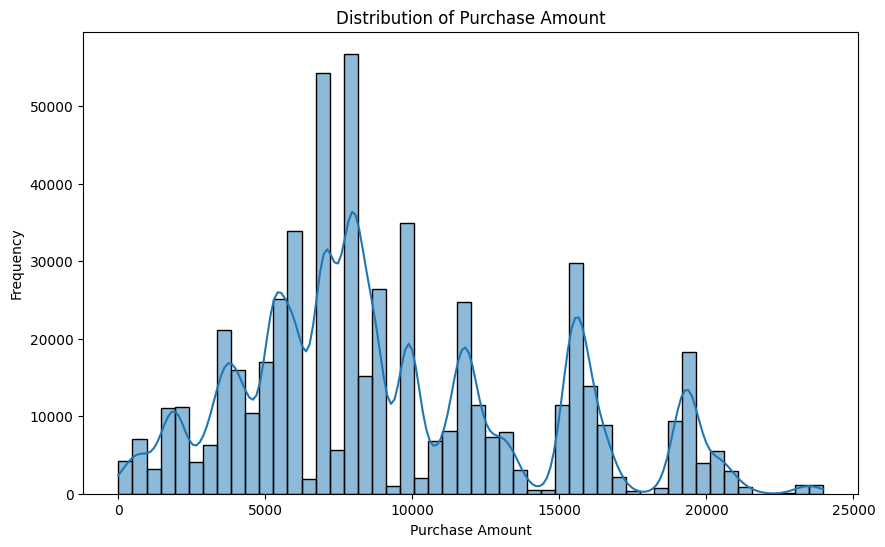

In [33]:
plt.figure(figsize=(10, 6))

sns.histplot(df['Purchase'], bins=50, kde=True)

plt.title('Distribution of Purchase Amount')
plt.xlabel('Purchase Amount')
plt.ylabel('Frequency')

plt.show()

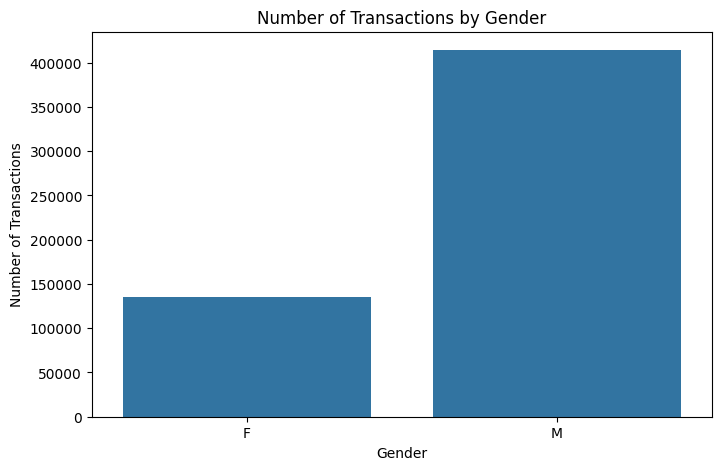

In [34]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Gender')

plt.title('Number of Transactions by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Transactions')

plt.show()

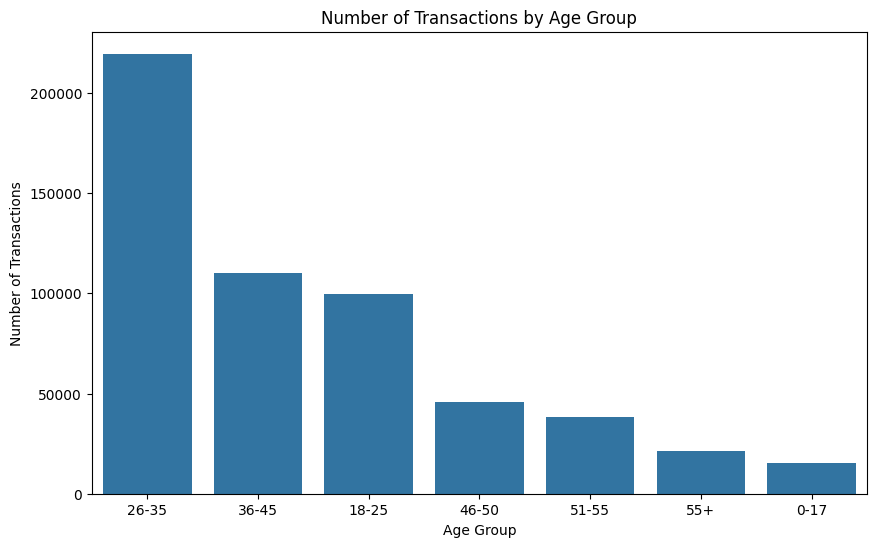

In [35]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x='Age', order=df['Age'].value_counts().index)

plt.title('Number of Transactions by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Transactions')

plt.show()

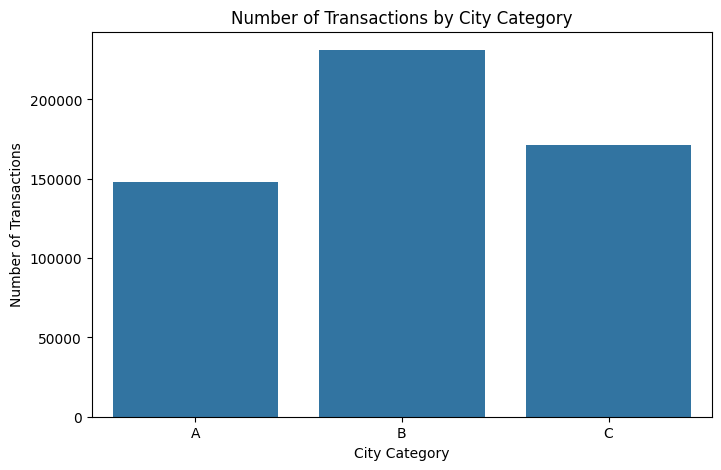

In [36]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='City_Category')

plt.title('Number of Transactions by City Category')
plt.xlabel('City Category')
plt.ylabel('Number of Transactions')

plt.show()

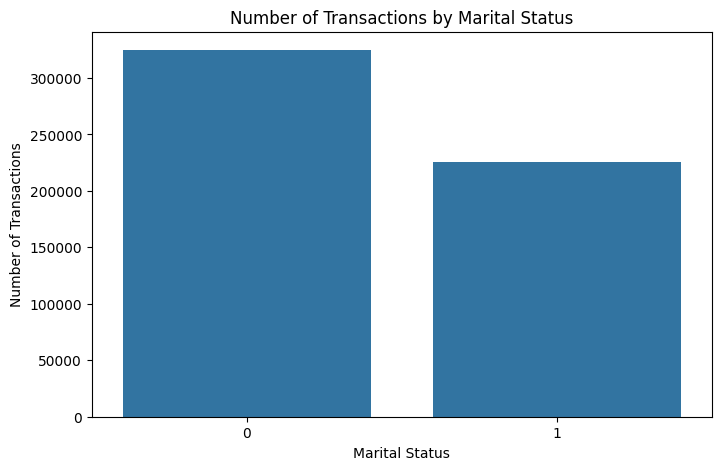

In [37]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Marital_Status')

plt.title('Number of Transactions by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Number of Transactions')

plt.show()

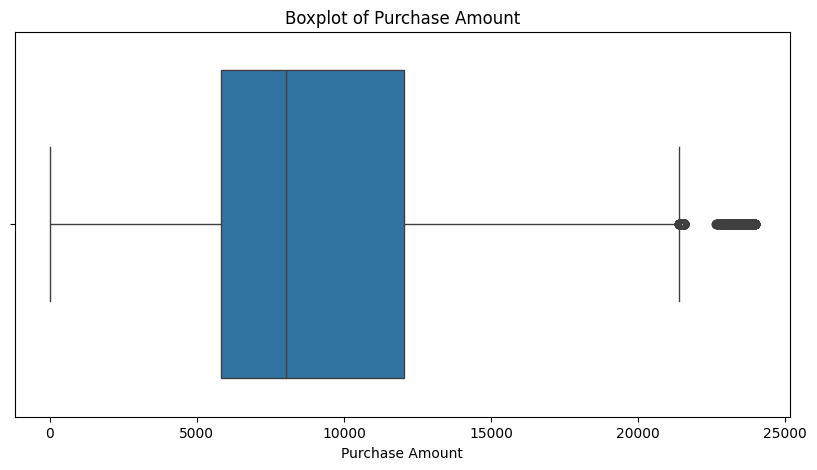

In [38]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df['Purchase'])

plt.title('Boxplot of Purchase Amount')
plt.xlabel('Purchase Amount')

plt.show()

In [39]:
Q1 = df['Purchase'].quantile(0.25)
Q3 = df['Purchase'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 5823.0
Q3: 12054.0
IQR: 6231.0
Lower Bound: -3523.5
Upper Bound: 21400.5


In [40]:
outliers = df[
    (df['Purchase'] < lower_bound) |
    (df['Purchase'] > upper_bound)
]

print("Number of outliers:", len(outliers))
print("Percentage of outliers:", len(outliers) / len(df) * 100)

Number of outliers: 2677
Percentage of outliers: 0.4866671029763593


In [41]:
gender_summary = df.groupby('Gender', observed=True)['Purchase'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

gender_summary

,count,mean,median,std,min,max
Gender,,,,,,
F,135809,8734.57,7914.00,4767.23,12,23959
M,414259,9437.53,8098.00,5092.19,12,23961


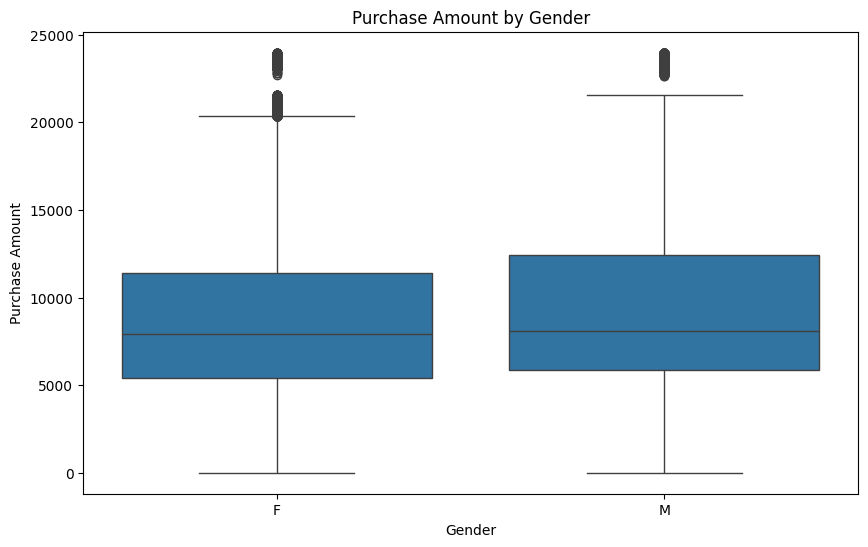

In [42]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='Gender', y='Purchase')

plt.title('Purchase Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Purchase Amount')

plt.show()

In [43]:
female_mean = df[df['Gender'] == 'F']['Purchase'].mean()
male_mean = df[df['Gender'] == 'M']['Purchase'].mean()

print("Average Female Purchase:", female_mean)
print("Average Male Purchase:", male_mean)

difference = male_mean - female_mean

print("Difference between Male and Female Average:", difference)
print("Percentage difference:", (difference / female_mean) * 100)

Average Female Purchase: 8734.565765155476
Average Male Purchase: 9437.526040472265
Difference between Male and Female Average: 702.9602753167892
Percentage difference: 8.048027735060238


In [44]:
if male_mean > female_mean:
    print("Conclusion: Male customers spend more per transaction than female customers.")
else:
    print("Conclusion: Female customers spend more per transaction than male customers.")

Conclusion: Male customers spend more per transaction than female customers.


In [45]:
female_data = df[df['Gender'] == 'F']['Purchase']
male_data = df[df['Gender'] == 'M']['Purchase']

print("Female sample size:", len(female_data))
print("Male sample size:", len(male_data))

Female sample size: 135809
Male sample size: 414259


In [46]:
def confidence_interval(data, confidence=0.95):

    n = len(data)
    mean = np.mean(data)
    std = np.std(data, ddof=1)

    standard_error = std / np.sqrt(n)

    z_score = norm.ppf(1 - (1-confidence)/2)

    margin_of_error = z_score * standard_error

    lower = mean - margin_of_error
    upper = mean + margin_of_error

    return mean, standard_error, margin_of_error, lower, upper

In [47]:
female_mean, female_se, female_margin, female_lower, female_upper = confidence_interval(
    female_data,
    confidence=0.95
)

print("Female Mean:", female_mean)
print("Female Standard Error:", female_se)
print("Female Margin of Error:", female_margin)
print("Female 95% CI:", (female_lower, female_upper))

Female Mean: 8734.565765155476
Female Standard Error: 12.936063220950688
Female Margin of Error: 25.354218014796555
Female 95% CI: (np.float64(8709.21154714068), np.float64(8759.919983170272))


In [48]:
male_mean, male_se, male_margin, male_lower, male_upper = confidence_interval(
    male_data,
    confidence=0.95
)

print("Male Mean:", male_mean)
print("Male Standard Error:", male_se)
print("Male Margin of Error:", male_margin)
print("Male 95% CI:", (male_lower, male_upper))

Male Mean: 9437.526040472265
Male Standard Error: 7.91167247562093
Male Margin of Error: 15.50659310969387
Male 95% CI: (np.float64(9422.01944736257), np.float64(9453.032633581959))


In [49]:
print(f"Female 95% CI: ({female_lower:.2f}, {female_upper:.2f})")
print(f"Male 95% CI: ({male_lower:.2f}, {male_upper:.2f})")

Female 95% CI: (8709.21, 8759.92)
Male 95% CI: (9422.02, 9453.03)


In [50]:
if female_upper < male_lower or male_upper < female_lower:
    print("The confidence intervals DO NOT overlap.")
else:
    print("The confidence intervals overlap.")

The confidence intervals DO NOT overlap.


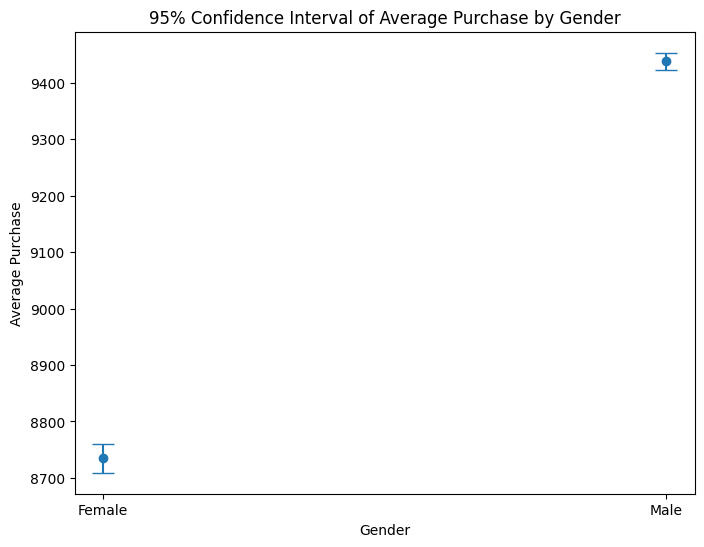

In [51]:
groups = ['Female', 'Male']

means = [female_mean, male_mean]

lower_errors = [
    female_mean - female_lower,
    male_mean - male_lower
]

upper_errors = [
    female_upper - female_mean,
    male_upper - male_mean
]

plt.figure(figsize=(8, 6))

plt.errorbar(
    groups,
    means,
    yerr=[lower_errors, upper_errors],
    fmt='o',
    capsize=8
)

plt.title('95% Confidence Interval of Average Purchase by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Purchase')

plt.show()

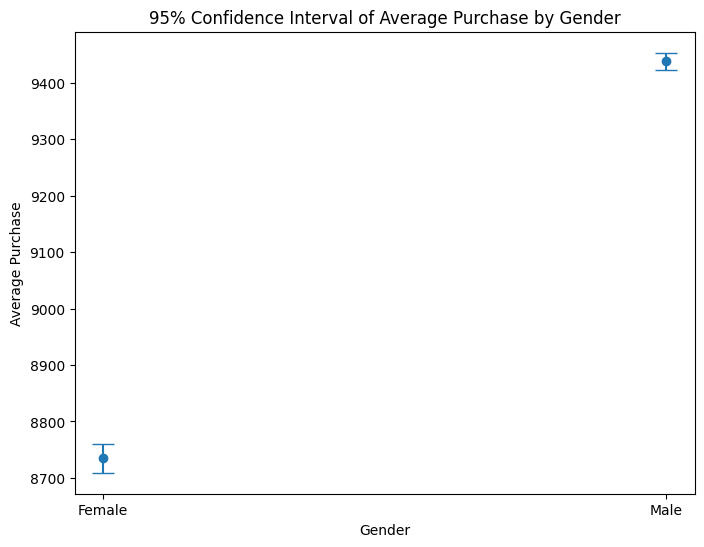

In [52]:
groups = ['Female', 'Male']

means = [female_mean, male_mean]

lower_errors = [
    female_mean - female_lower,
    male_mean - male_lower
]

upper_errors = [
    female_upper - female_mean,
    male_upper - male_mean
]

plt.figure(figsize=(8, 6))

plt.errorbar(
    groups,
    means,
    yerr=[lower_errors, upper_errors],
    fmt='o',
    capsize=8
)

plt.title('95% Confidence Interval of Average Purchase by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Purchase')

plt.show()

In [53]:
confidence_levels = [0.90, 0.95, 0.99]

for level in confidence_levels:

    _, _, _, lower, upper = confidence_interval(
        female_data,
        confidence=level
    )

    print(f"Female {level*100:.0f}% CI: ({lower:.2f}, {upper:.2f})")

Female 90% CI: (8713.29, 8755.84)
Female 95% CI: (8709.21, 8759.92)
Female 99% CI: (8701.24, 8767.89)


In [54]:
for level in confidence_levels:

    _, _, _, lower, upper = confidence_interval(
        male_data,
        confidence=level
    )

    print(f"Male {level*100:.0f}% CI: ({lower:.2f}, {upper:.2f})")

Male 90% CI: (9424.51, 9450.54)
Male 95% CI: (9422.02, 9453.03)
Male 99% CI: (9417.15, 9457.91)


In [55]:
def sampling_distribution(data, sample_size, repetitions=1000):

    sample_means = []

    for i in range(repetitions):
        sample = np.random.choice(
            data,
            size=sample_size,
            replace=False
        )

        sample_means.append(np.mean(sample))

    return sample_means

In [56]:
def sampling_distribution(data, sample_size, repetitions=1000):

    sample_means = []

    for i in range(repetitions):
        sample = np.random.choice(
            data,
            size=sample_size,
            replace=False
        )

        sample_means.append(np.mean(sample))

    return sample_means

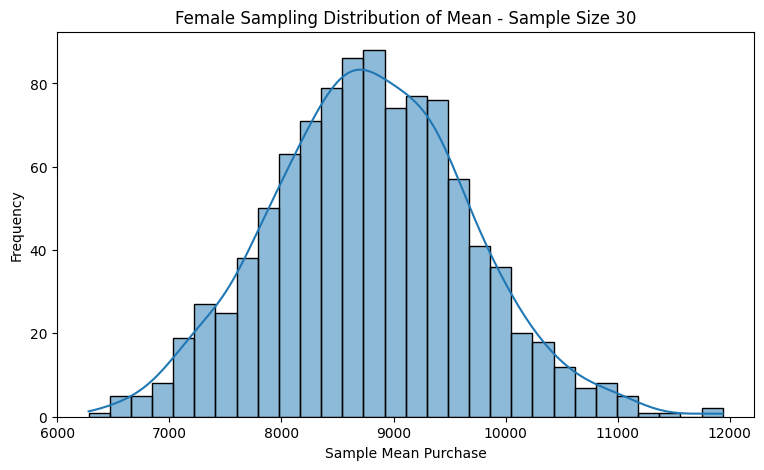

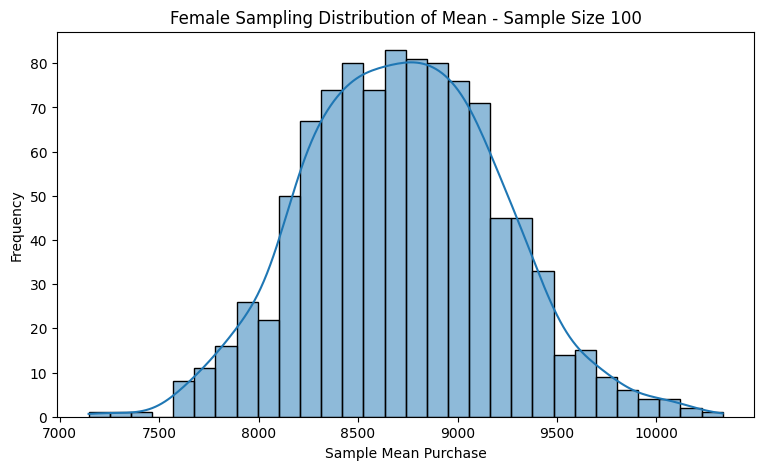

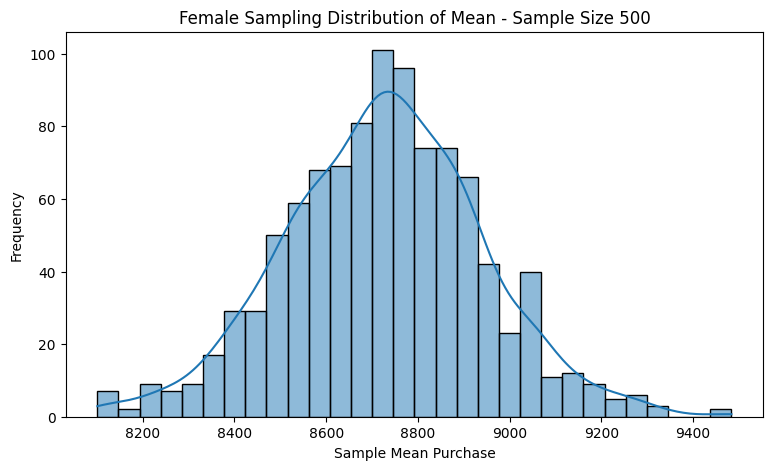

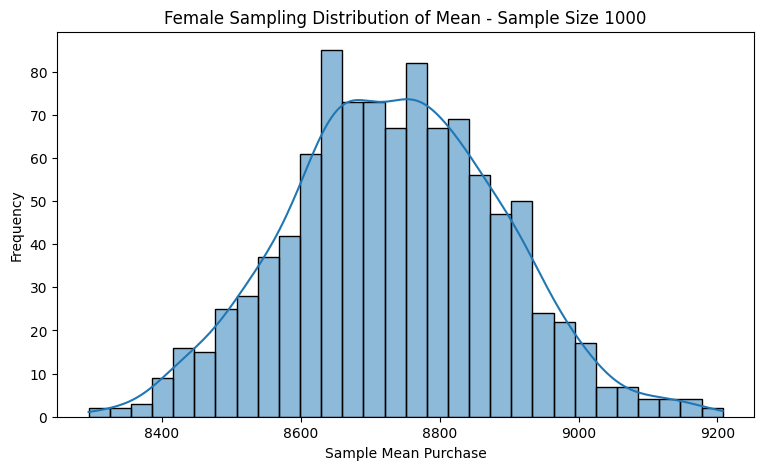

In [57]:
sample_sizes = [30, 100, 500, 1000]

for size in sample_sizes:

    means = sampling_distribution(
        female_data.values,
        size,
        repetitions=1000
    )

    plt.figure(figsize=(9, 5))

    sns.histplot(means, bins=30, kde=True)

    plt.title(f'Female Sampling Distribution of Mean - Sample Size {size}')
    plt.xlabel('Sample Mean Purchase')
    plt.ylabel('Frequency')

    plt.show()

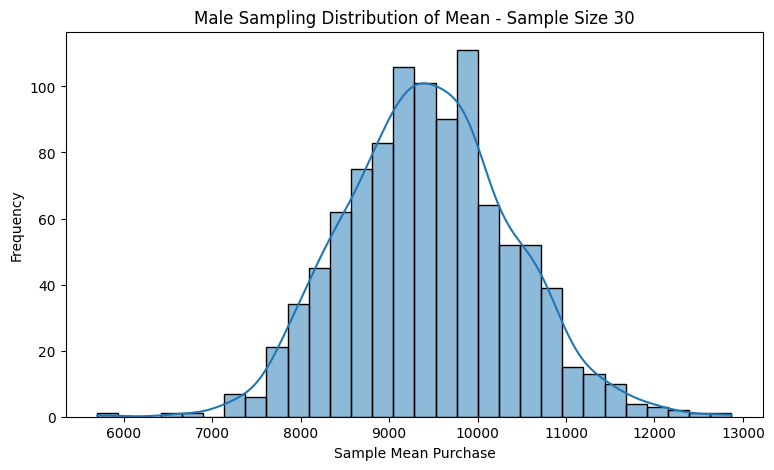

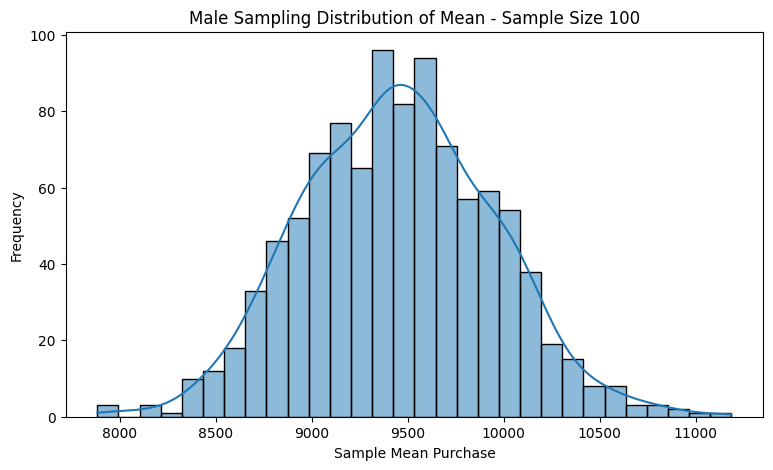

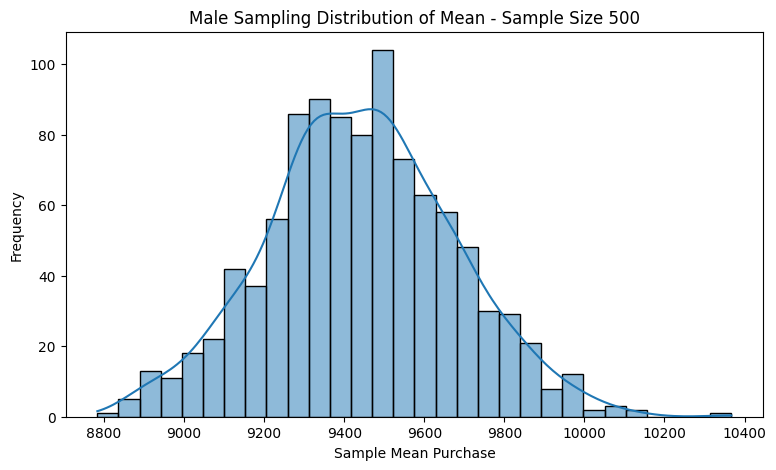

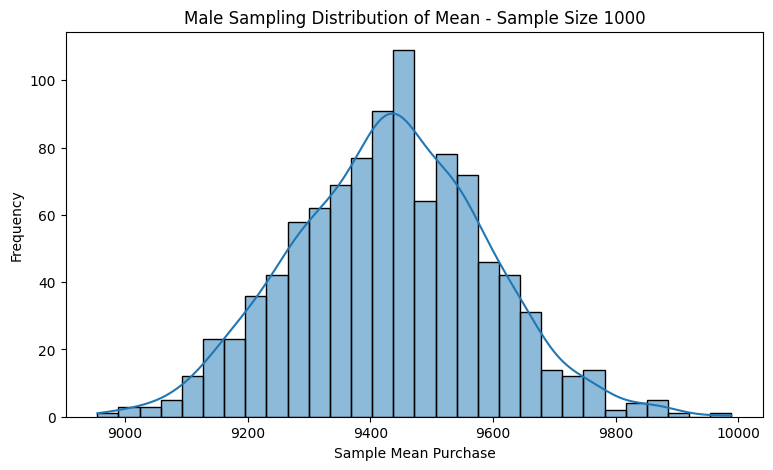

In [58]:
for size in sample_sizes:

    means = sampling_distribution(
        male_data.values,
        size,
        repetitions=1000
    )

    plt.figure(figsize=(9, 5))

    sns.histplot(means, bins=30, kde=True)

    plt.title(f'Male Sampling Distribution of Mean - Sample Size {size}')
    plt.xlabel('Sample Mean Purchase')
    plt.ylabel('Frequency')

    plt.show()

In [59]:
female_std = female_data.std()
male_std = male_data.std()

sample_sizes = [30, 100, 500, 1000, 5000, 10000]

results = []

for n in sample_sizes:

    female_se = female_std / np.sqrt(n)
    male_se = male_std / np.sqrt(n)

    results.append([
        n,
        female_se,
        male_se
    ])

clt_se_df = pd.DataFrame(
    results,
    columns=['Sample Size', 'Female SE', 'Male SE']
)

clt_se_df

,Sample Size,Female SE,Male SE
0,30,870.37,929.70
1,100,476.72,509.22
2,500,213.20,227.73
3,1000,150.75,161.03
4,5000,67.42,72.01
5,10000,47.67,50.92


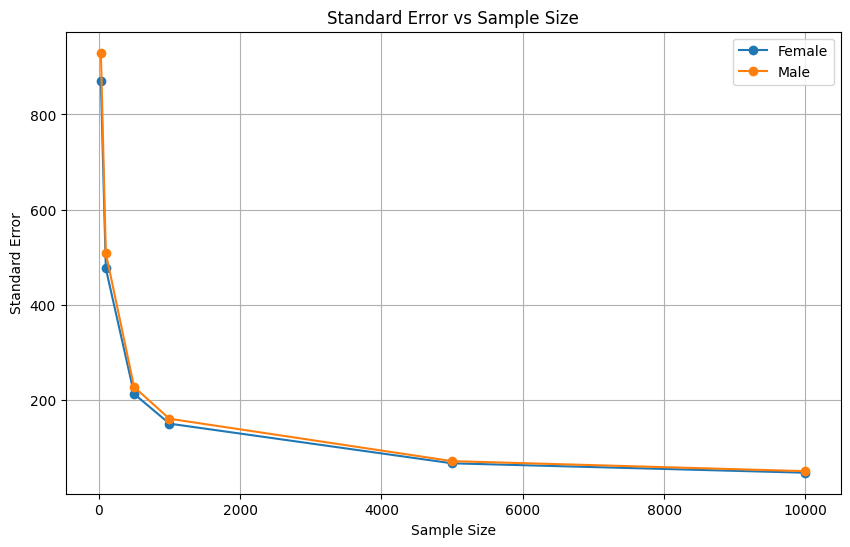

In [60]:
plt.figure(figsize=(10, 6))

plt.plot(
    clt_se_df['Sample Size'],
    clt_se_df['Female SE'],
    marker='o',
    label='Female'
)

plt.plot(
    clt_se_df['Sample Size'],
    clt_se_df['Male SE'],
    marker='o',
    label='Male'
)

plt.title('Standard Error vs Sample Size')
plt.xlabel('Sample Size')
plt.ylabel('Standard Error')

plt.legend()
plt.grid(True)

plt.show()

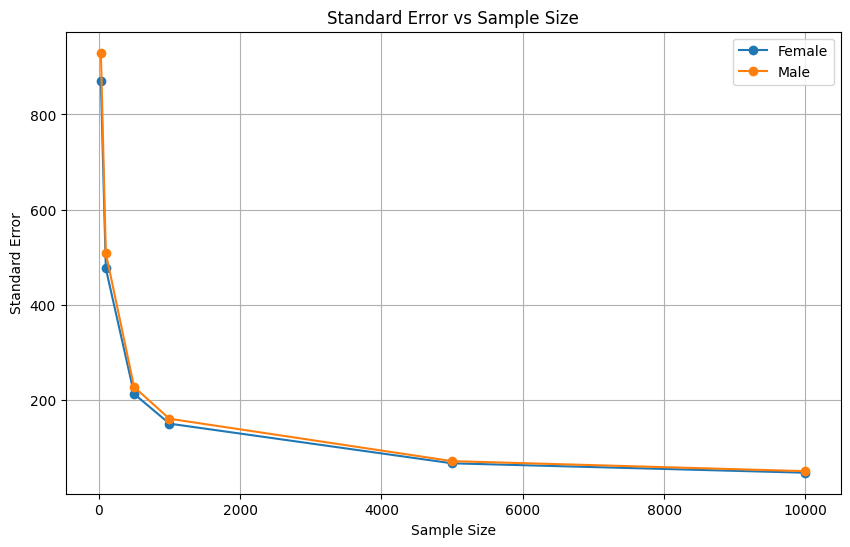

In [61]:
plt.figure(figsize=(10, 6))

plt.plot(
    clt_se_df['Sample Size'],
    clt_se_df['Female SE'],
    marker='o',
    label='Female'
)

plt.plot(
    clt_se_df['Sample Size'],
    clt_se_df['Male SE'],
    marker='o',
    label='Male'
)

plt.title('Standard Error vs Sample Size')
plt.xlabel('Sample Size')
plt.ylabel('Standard Error')

plt.legend()
plt.grid(True)

plt.show()

In [62]:
marital_summary = df.groupby('Marital_Status', observed=True)['Purchase'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

marital_summary

,count,mean,median,std,min,max
Marital_Status,,,,,,
0,324731,9265.91,8044.00,5027.35,12,23961
1,225337,9261.17,8051.00,5016.90,12,23961


In [63]:
df['Marital_Status_Label'] = df['Marital_Status'].map({
    0: 'Unmarried',
    1: 'Married'
})

df['Marital_Status_Label'].value_counts()

,count
Marital_Status_Label,
Unmarried,324731
Married,225337


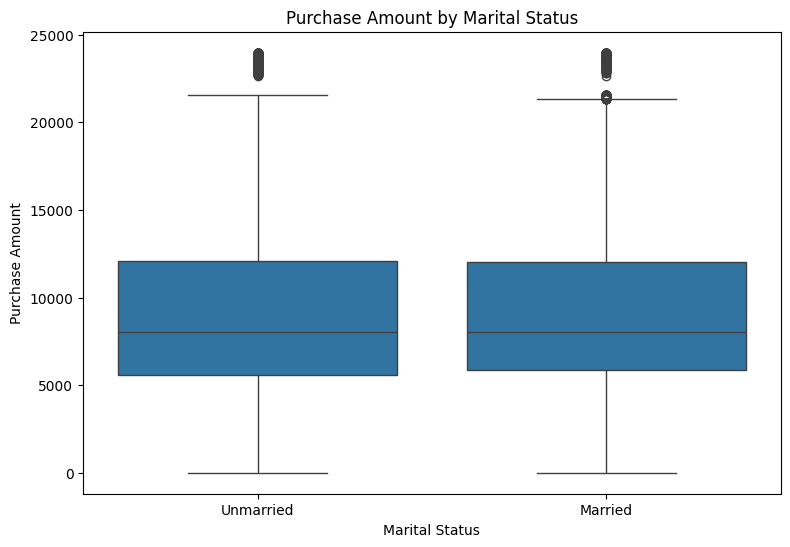

In [64]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x='Marital_Status_Label',
    y='Purchase'
)

plt.title('Purchase Amount by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Purchase Amount')

plt.show()

In [65]:
married_data = df[
    df['Marital_Status'] == 1
]['Purchase']

unmarried_data = df[
    df['Marital_Status'] == 0
]['Purchase']

In [66]:
married_results = confidence_interval(
    married_data,
    confidence=0.95
)

unmarried_results = confidence_interval(
    unmarried_data,
    confidence=0.95
)

print("Married 95% CI:")
print(married_results)

print("\nUnmarried 95% CI:")
print(unmarried_results)

Married 95% CI:
(np.float64(9261.174574082374), np.float64(10.568636561021444), np.float64(20.714147025295283), np.float64(9240.460427057078), np.float64(9281.888721107669))

Unmarried 95% CI:
(np.float64(9265.907618921507), np.float64(8.82220330129379), np.float64(17.291200734826194), np.float64(9248.61641818668), np.float64(9283.198819656332))


In [67]:
married_results = confidence_interval(
    married_data,
    confidence=0.95
)

unmarried_results = confidence_interval(
    unmarried_data,
    confidence=0.95
)

print("Married 95% CI:")
print(married_results)

print("\nUnmarried 95% CI:")
print(unmarried_results)

Married 95% CI:
(np.float64(9261.174574082374), np.float64(10.568636561021444), np.float64(20.714147025295283), np.float64(9240.460427057078), np.float64(9281.888721107669))

Unmarried 95% CI:
(np.float64(9265.907618921507), np.float64(8.82220330129379), np.float64(17.291200734826194), np.float64(9248.61641818668), np.float64(9283.198819656332))


In [69]:
def create_age_group(age):

    if age == '0-17':
        return '0-17'

    elif age == '18-25':
        return '18-25'

    elif age == '26-35':
        return '26-35'

    elif age in ['36-45', '46-50']:
        return '36-50'

    else:
        return '51+'

df['Age_Group'] = df['Age'].apply(create_age_group)

In [70]:
df['Age_Group'].value_counts()

,count
Age_Group,
26-35,219587
36-50,155714
18-25,99660
51+,60005
0-17,15102


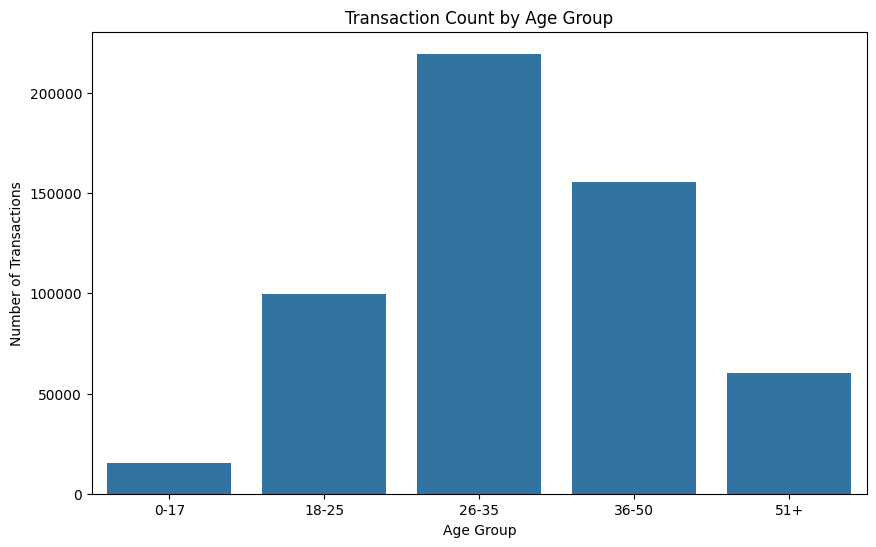

In [71]:
age_order = ['0-17', '18-25', '26-35', '36-50', '51+']

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='Age_Group',
    order=age_order
)

plt.title('Transaction Count by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Transactions')

plt.show()

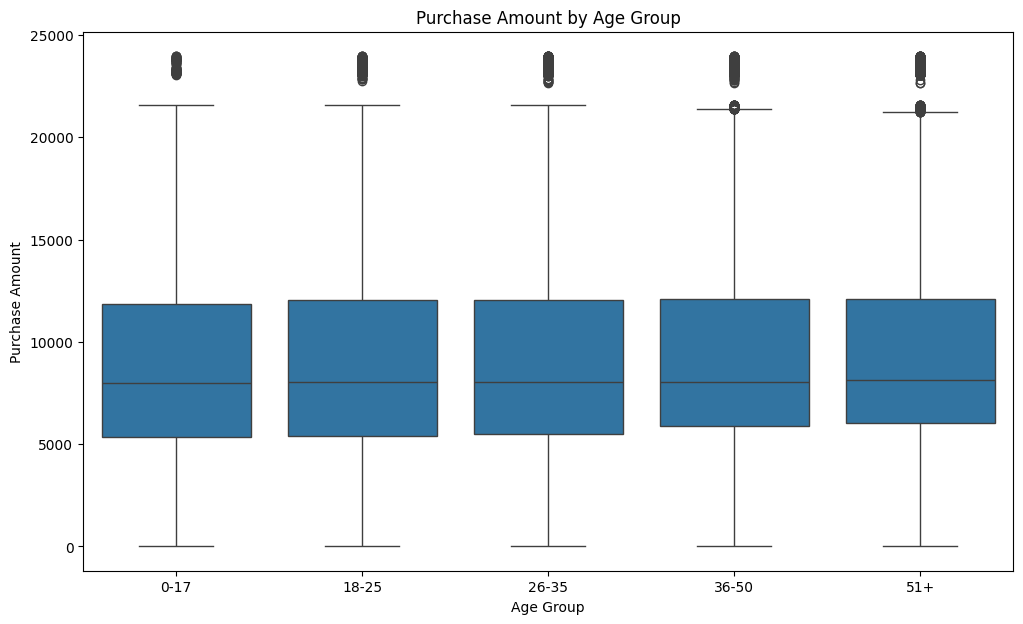

In [72]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df,
    x='Age_Group',
    y='Purchase',
    order=age_order
)

plt.title('Purchase Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Purchase Amount')

plt.show()

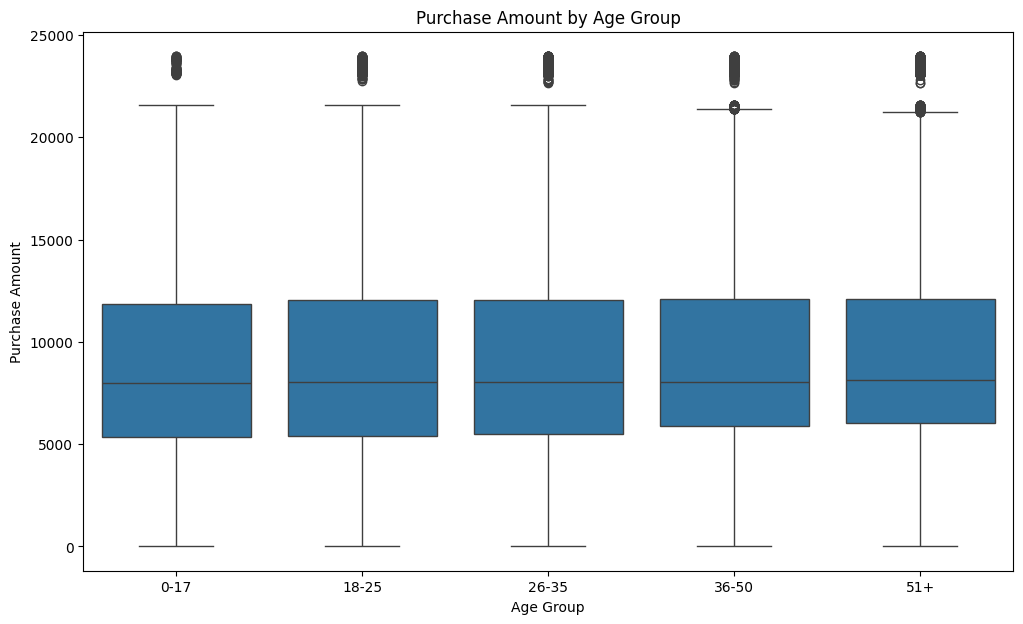

In [73]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df,
    x='Age_Group',
    y='Purchase',
    order=age_order
)

plt.title('Purchase Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Purchase Amount')

plt.show()

In [74]:
age_ci_results = []

for age_group in age_order:

    data = df[
        df['Age_Group'] == age_group
    ]['Purchase']

    mean, se, margin, lower, upper = confidence_interval(
        data,
        confidence=0.95
    )

    age_ci_results.append([
        age_group,
        len(data),
        mean,
        se,
        lower,
        upper
    ])

age_ci_df = pd.DataFrame(
    age_ci_results,
    columns=[
        'Age Group',
        'Sample Size',
        'Mean',
        'Standard Error',
        'CI Lower',
        'CI Upper'
    ]
)

age_ci_df

,Age Group,Sample Size,Mean,Standard Error,CI Lower,CI Upper
0,0-17,15102,8933.46,41.59,8851.95,9014.98
1,18-25,99660,9169.66,15.95,9138.41,9200.92
2,26-35,219587,9252.69,10.69,9231.73,9273.65
3,36-50,155714,9295.33,12.69,9270.46,9320.20
4,51+,60005,9463.66,20.66,9423.17,9504.16


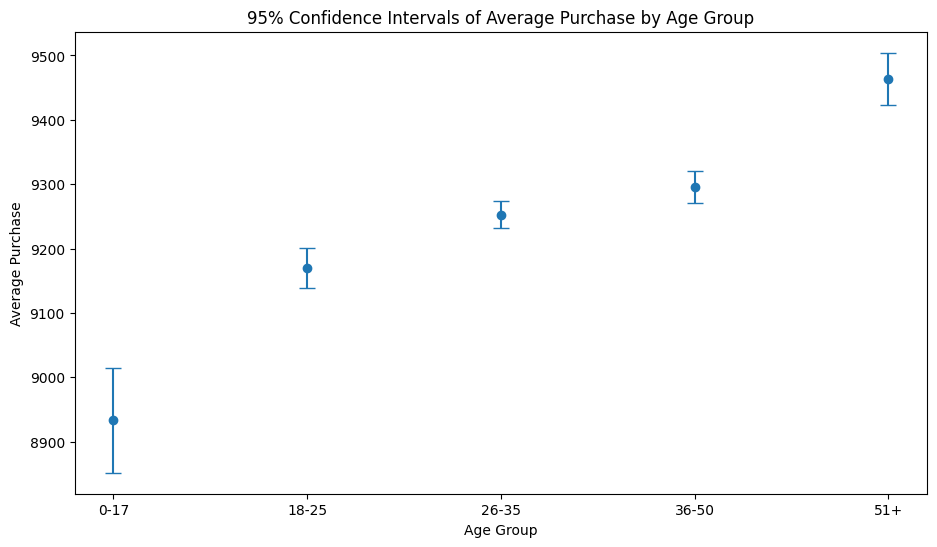

In [75]:
plt.figure(figsize=(11, 6))

plt.errorbar(
    age_ci_df['Age Group'],
    age_ci_df['Mean'],
    yerr=[
        age_ci_df['Mean'] - age_ci_df['CI Lower'],
        age_ci_df['CI Upper'] - age_ci_df['Mean']
    ],
    fmt='o',
    capsize=6
)

plt.title('95% Confidence Intervals of Average Purchase by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Purchase')

plt.show()

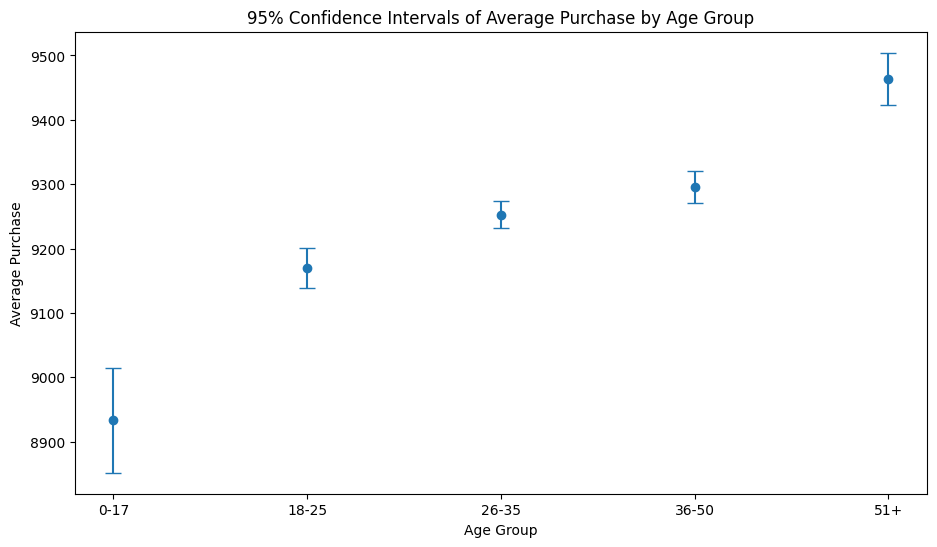

In [76]:
plt.figure(figsize=(11, 6))

plt.errorbar(
    age_ci_df['Age Group'],
    age_ci_df['Mean'],
    yerr=[
        age_ci_df['Mean'] - age_ci_df['CI Lower'],
        age_ci_df['CI Upper'] - age_ci_df['Mean']
    ],
    fmt='o',
    capsize=6
)

plt.title('95% Confidence Intervals of Average Purchase by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Purchase')

plt.show()

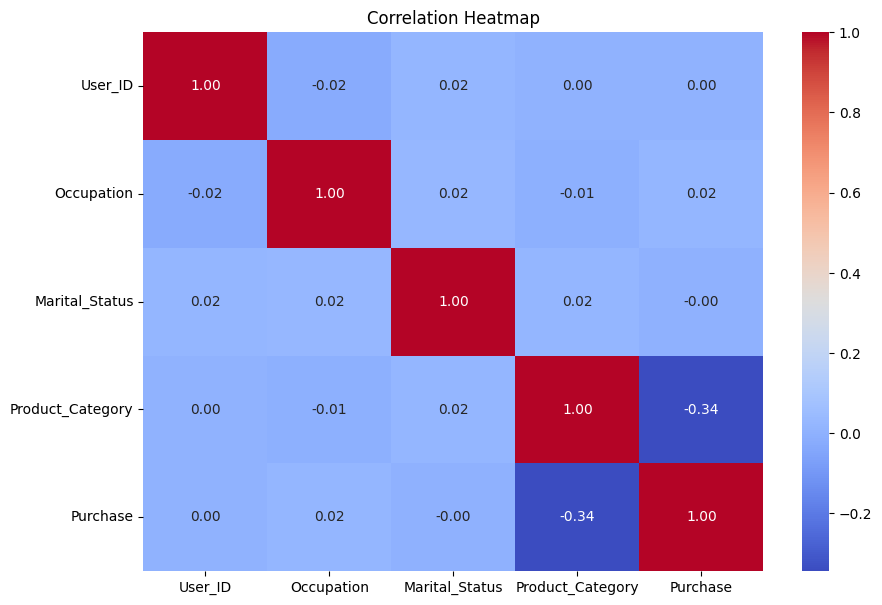

In [77]:
plt.figure(figsize=(10, 7))

numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

In [78]:
city_summary = df.groupby(
    'City_Category',
    observed=True
)['Purchase'].agg(
    ['count', 'mean', 'median', 'std']
)

city_summary

,count,mean,median,std
City_Category,,,,
A,147720,8911.94,7931.00,4892.12
B,231173,9151.30,8005.00,4955.50
C,171175,9719.92,8585.00,5189.47


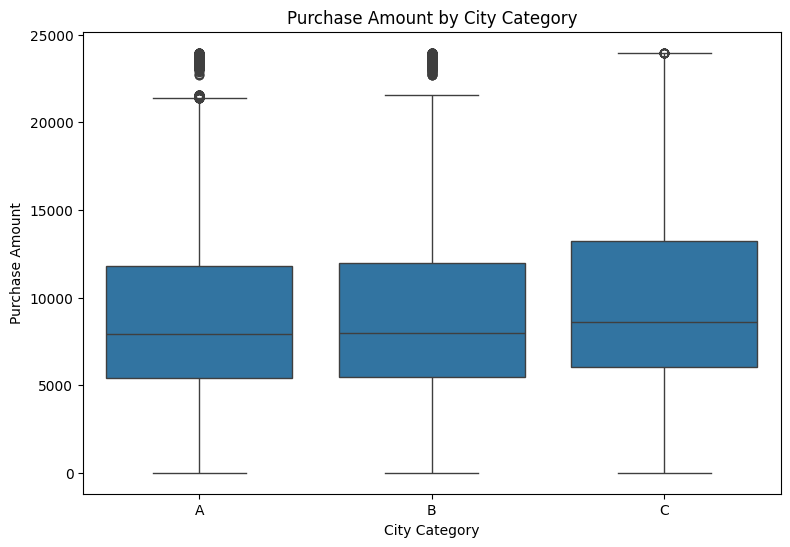

In [79]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x='City_Category',
    y='Purchase'
)

plt.title('Purchase Amount by City Category')
plt.xlabel('City Category')
plt.ylabel('Purchase Amount')

plt.show()

In [80]:
stay_summary = df.groupby(
    'Stay_In_Current_City_Years',
    observed=True
)['Purchase'].agg(
    ['count', 'mean', 'median', 'std']
)

stay_summary

,count,mean,median,std
Stay_In_Current_City_Years,,,,
0,74398,9180.08,8025.00,4990.48
1,193821,9250.15,8041.00,5027.48
2,101838,9320.43,8072.00,5044.59
3,95285,9286.90,8047.00,5020.34
4+,84726,9275.60,8052.00,5017.63


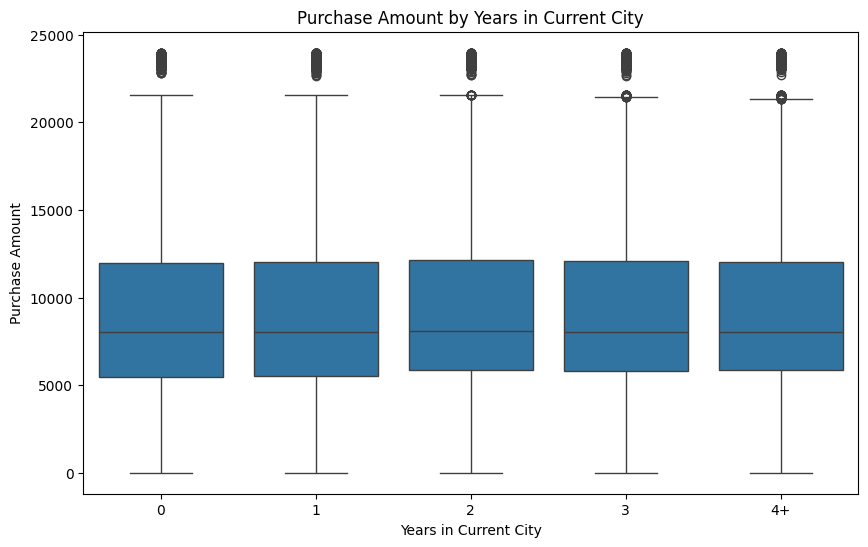

In [81]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Stay_In_Current_City_Years',
    y='Purchase'
)

plt.title('Purchase Amount by Years in Current City')
plt.xlabel('Years in Current City')
plt.ylabel('Purchase Amount')

plt.show()

In [82]:
product_summary = df.groupby(
    'Product_Category'
)['Purchase'].agg(
    ['count', 'mean', 'median', 'std']
).sort_values(
    'mean',
    ascending=False
)

product_summary.head(10)

,count,mean,median,std
Product_Category,,,,
10,5125,19675.57,19197.00,4225.72
7,3721,16365.69,16700.00,4174.55
6,20466,15838.48,16312.00,4011.23
9,410,15537.38,14388.50,5330.85
15,6290,14780.45,16660.00,5175.47
16,9828,14766.04,16292.50,4360.21
1,140378,13606.22,15245.00,4298.83
14,1523,13141.63,14654.00,4069.01
2,23864,11251.94,12728.50,3570.64


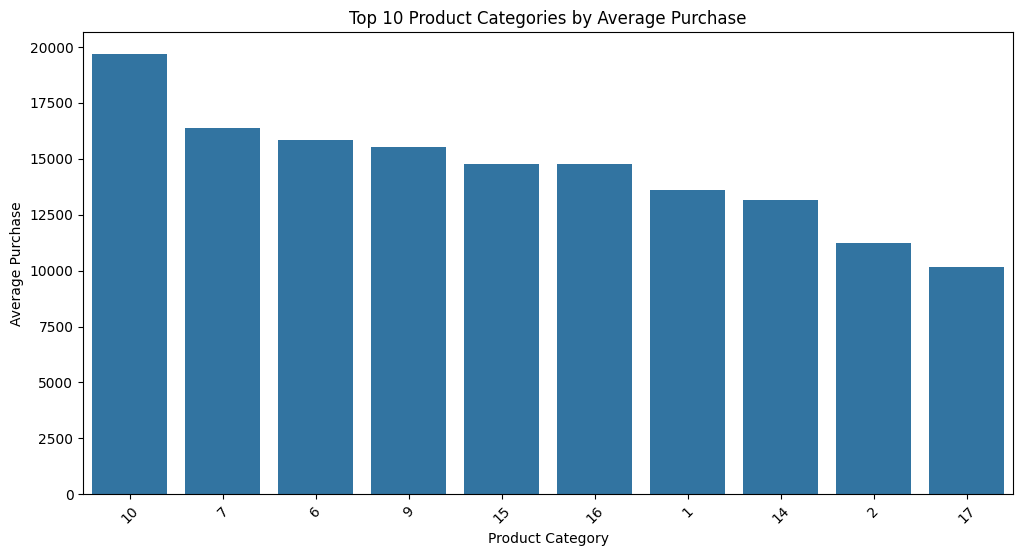

In [83]:
top_categories = product_summary.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_categories.index.astype(str),
    y=top_categories['mean']
)

plt.title('Top 10 Product Categories by Average Purchase')
plt.xlabel('Product Category')
plt.ylabel('Average Purchase')

plt.xticks(rotation=45)

plt.show()

In [84]:
overall_summary = pd.DataFrame({
    'Metric': [
        'Total Transactions',
        'Unique Customers',
        'Unique Products',
        'Average Purchase',
        'Median Purchase',
        'Minimum Purchase',
        'Maximum Purchase'
    ],

    'Value': [
        len(df),
        df['User_ID'].nunique(),
        df['Product_ID'].nunique(),
        df['Purchase'].mean(),
        df['Purchase'].median(),
        df['Purchase'].min(),
        df['Purchase'].max()
    ]
})

overall_summary

,Metric,Value
0,Total Transactions,550068.00
1,Unique Customers,5891.00
2,Unique Products,3631.00
3,Average Purchase,9263.97
4,Median Purchase,8047.00
5,Minimum Purchase,12.00
6,Maximum Purchase,23961.00


In [85]:
gender_ci_table = []

for gender in ['F', 'M']:

    data = df[df['Gender'] == gender]['Purchase']

    mean, se, margin, lower, upper = confidence_interval(
        data,
        confidence=0.95
    )

    gender_ci_table.append([
        gender,
        len(data),
        mean,
        data.median(),
        data.std(),
        lower,
        upper
    ])

gender_ci_table = pd.DataFrame(
    gender_ci_table,
    columns=[
        'Gender',
        'Sample Size',
        'Mean',
        'Median',
        'Std Dev',
        '95% CI Lower',
        '95% CI Upper'
    ]
)

gender_ci_table

,Gender,Sample Size,Mean,Median,Std Dev,95% CI Lower,95% CI Upper
0,F,135809,8734.57,7914.00,4767.23,8709.21,8759.92
1,M,414259,9437.53,8098.00,5092.19,9422.02,9453.03


## Final Business Insights

1. The Walmart Black Friday dataset contains a large number of transactions and provides a useful sample for understanding customer purchase behavior.

2. The Purchase variable is right-skewed because the mean is higher than the median. High-value transactions contribute to the higher average.

3. There are no missing values in the dataset, so no missing-value treatment is required.

4. The dataset contains high-value purchase outliers. These transactions have been retained because they may represent genuine customer purchases and are important from a business perspective.

5. Male customers have a higher average purchase amount than female customers.

6. The confidence intervals for male and female average spending do not overlap, indicating a meaningful difference in average purchase behavior.

7. The Central Limit Theorem demonstrates that as sample size increases, the distribution of sample means becomes more concentrated around the population mean and the standard error decreases.

8. Increasing the confidence level from 90% to 95% and then 99% results in wider confidence intervals.

9. Married and unmarried customers have very similar average purchase amounts and their confidence intervals overlap substantially. Therefore, marital status is not a strong differentiator of average spending.

10. The 26–35 age group has the highest transaction volume and is an important segment for Walmart.

11. Older customers, particularly the 51+ segment, show relatively high average transaction values and may represent an important high-value customer segment.

12. Walmart should therefore use different strategies for high-volume customer segments and high-value customer segments.

## Recommendations

### 1. Increase Female Customer Spending

Female customers have a lower average transaction value than male customers. Walmart should investigate female product preferences and introduce targeted bundles, promotions and personalized recommendations.

### 2. Retain High-Value Male Customers

Male customers have a higher average purchase value. Walmart should use loyalty benefits, cross-selling and personalized recommendations to retain these customers.

### 3. Target the 26–35 Age Group

The 26–35 age group has the largest transaction volume. Walmart should continue to target this group with digital offers, app-based promotions, flash sales and product bundles.

### 4. Target the 51+ Segment

The older customer segment has a relatively high average transaction value. Walmart can develop premium offers, convenience-focused services and loyalty benefits for this segment.

### 5. Do Not Overuse Marital Status

Married and unmarried customers have similar average spending. Therefore, Walmart should not make major marketing decisions based only on marital status.

### 6. Use Personalized Marketing

Walmart should combine demographic information with product preferences and previous purchase behavior to create more relevant offers.

### 7. Track Both Volume and Value

Walmart should monitor both transaction volume and average transaction value. A segment with many transactions is not necessarily the segment with the highest spending per transaction.

### 8. Use Data-Driven Segmentation

Instead of treating all customers equally, Walmart should create targeted campaigns based on gender, age, product category and purchasing behavior.